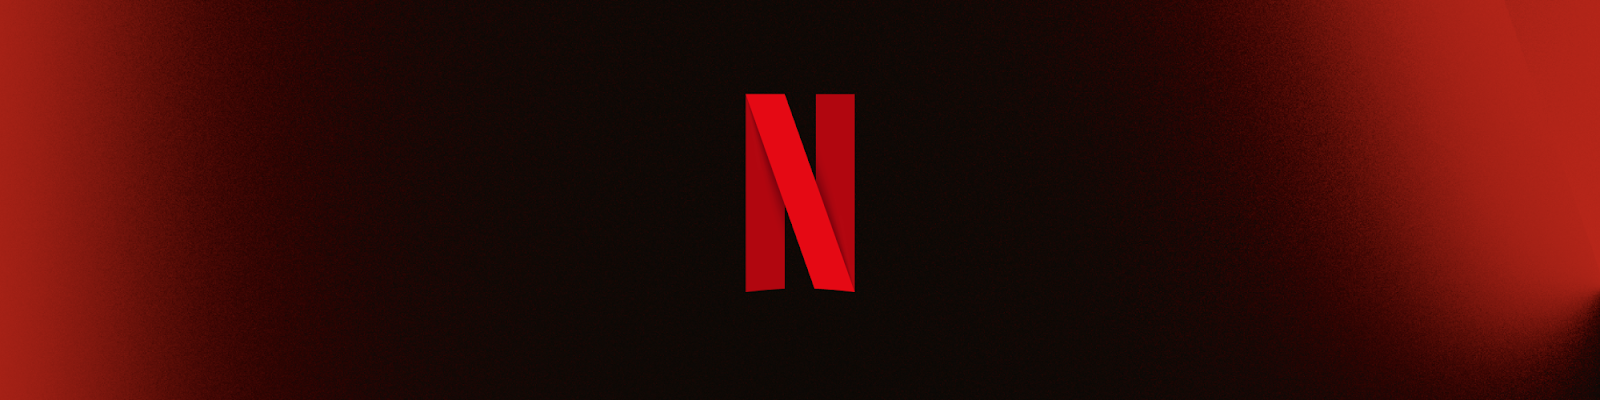

## **Exploratory Data Analysis - Customer Support**

**Data Analyst**: Aska Victoria Pereira Moreno

**Objective**: To deeply understand the data before building analytical models, dashboards, or business recommendations.


**Libraries Used**
- Pandas
- Numpy

## **Installing libraries**

In [ ]:
## Installing libraries
! pip install pandas numpy

In [ ]:
import pandas as pd
import numpy as np

## Extraction

In [ ]:
import pandas as pd

file_path = "/content/Aska - Takehome Exercise - CS Data Analyst.xlsx"
dfs = pd.read_excel(file_path, sheet_name=None)


In [ ]:
dfs.keys()  # view tab names

dict_keys(['Skill Data', 'Call Center Data', 'Capacity Plan to Skills', 'Sheet4'])

In [ ]:
# creating dataframes
df_skill = dfs["Skill Data"]
df_call_center = dfs["Call Center Data"]
df_capacity_skills = dfs["Capacity Plan to Skills"]

## Pre Analysis


In [ ]:
# overview function
def overview(df, name):
    print("\n" + "="*60)
    print(f"TABLE: {name}")
    print("="*60)

    print("\nShape:", df.shape)

    print("\nData type:")
    print(df.dtypes)

    print("\nNull Values:")
    print(df.isna().sum())

    print("\nDuplicates:", df.duplicated().sum())

    print("\nPreview:")
    display(df.head())


In [ ]:
overview(df_skill, 'Skill Data')


TABLE: Skill Data

Shape: (1279, 10)

Data type:
Skill                                object
Skill ID                             object
Language                             object
Call Center                          object
UTC Week (Sun-Sat)           datetime64[ns]
[# Contacts at BPO Skill]             int64
[# Contacts Answered]                 int64
AHT                                 float64
[RCR %]                             float64
[ASA Secs]                          float64
dtype: object

Null Values:
Skill                          0
Skill ID                       0
Language                       0
Call Center                    0
UTC Week (Sun-Sat)             0
[# Contacts at BPO Skill]      0
[# Contacts Answered]          0
AHT                          285
[RCR %]                      286
[ASA Secs]                   285
dtype: int64

Duplicates: 0

Preview:


,Skill,Skill ID,Language,Call Center,UTC Week (Sun-Sat),[# Contacts at BPO Skill],[# Contacts Answered],AHT,[RCR %],[ASA Secs]
0,Chat | English ANZ,ANZ_EN,English,Vendor A Manila,2023-07-15,793,791,13.20,0.0697,28.0
1,Chat | English ANZ,ANZ_EN,English,Vendor A India,2023-07-15,523,523,13.66,0.0582,30.0
2,Chat | English ANZ,ANZ_EN,English,Vendor C Mumbai,2023-07-15,1234,1232,13.86,0.0852,19.0
3,Chat | English ANZ,ANZ_EN,English,Vendor B Cebu,2023-07-15,444,444,15.72,0.0713,15.0
4,Chat | English ANZ,ANZ_EN,English,Unknown Callcenter,2023-07-15,87,0,NaN,NaN,NaN


In [ ]:
overview(df_call_center, "Call Center Data")


TABLE: Call Center Data

Shape: (259, 5)

Data type:
Capacity Plan                                     object
Month, Day, Year of UTC Week (Sun-Sat)    datetime64[ns]
Call Center                                       object
Occupancy %                                      float64
Utilization %                                    float64
dtype: object

Null Values:
Capacity Plan                              0
Month, Day, Year of UTC Week (Sun-Sat)     0
Call Center                                0
Occupancy %                               60
Utilization %                             60
dtype: int64

Duplicates: 0

Preview:


,Capacity Plan,"Month, Day, Year of UTC Week (Sun-Sat)",Call Center,Occupancy %,Utilization %
0,APAC Bahasa Malay Voice,2023-07-22,Vendor E Malaysia,0.2774,0.2254
1,APAC Japanese,2023-07-22,Vendor E Japan,0.3528,0.2448
2,APAC Japanese Chat,2023-07-22,Vendor E Japan,0.3075,0.2458
3,APAC Japanese Voice,2023-07-22,Vendor E Japan,0.5340,0.4181
4,APAC Korean,2023-07-22,Vendor D Korea,0.4604,0.3466


In [ ]:
overview(df_capacity_skills, 'Capacity Plan to Skills')


TABLE: Capacity Plan to Skills

Shape: (10, 2)

Data type:
Capacity Plan    object
SKILLSET_NAME    object
dtype: object

Null Values:
Capacity Plan    0
SKILLSET_NAME    0
dtype: int64

Duplicates: 0

Preview:


,Capacity Plan,SKILLSET_NAME
0,APAC Bahasa Malay Voice,ms_MY
1,APAC Japanese Chat,JA
2,APAC Japanese Voice,ja_JP
3,APAC Korean Chat,KO
4,APAC Korean Voice,ko_KR


In [ ]:
# backups

df_skill_backup = df_skill.copy()
df_call_center_backup = df_call_center.copy()
df_capacity_skills_backup = df_capacity_skills.copy()

## Transform

In [ ]:
# Capacity_Plan_to_Skill table
df_capacity_skills

,Capacity Plan,SKILLSET_NAME
0,APAC Bahasa Malay Voice,ms_MY
1,APAC Japanese Chat,JA
2,APAC Japanese Voice,ja_JP
3,APAC Korean Chat,KO
4,APAC Korean Voice,ko_KR
5,Global English Chat,"INDIA_EN,US_EN,ASIA_EN,ANZ_EN,CA_EN,LA_EN,MEA_..."
6,Global English Chat,"US_EN,ASIA_EN,ANZ_EN,CA_EN,LA_EN,MEA_EN,GB_EN,..."
7,Global English Voice,"en_US,en_ASIA,en_CA,en_ANZ,en_GB,en_MEA"
8,Global English Voice,"en_US,en_ASIA,en_CA,en_ANZ,en_GB,en_MEA,tl_PH"
9,Global English Voice,"en_US,en_ASIA,en_LATAM,en_CA,en_ANZ,en_WEU,en_..."


In [ ]:
# separate skills with commas
df_capacity_skills["SKILLSET_NAME"] = (
    df_capacity_skills["SKILLSET_NAME"]
    .str.split(",")
)

# Transform list into multiple rows
df_capacity_skills = df_capacity_skills.explode("SKILLSET_NAME")

# clean spaces
df_capacity_skills["SKILLSET_NAME"] = (
    df_capacity_skills["SKILLSET_NAME"]
    .str.strip()
)



In [ ]:
df_capacity_skills.duplicated().any()

np.True_

In [ ]:
df_capacity_skills.duplicated().sum()

np.int64(21)

In [ ]:
df_capacity_skills[df_capacity_skills.duplicated(keep=False)]


,Capacity Plan,SKILLSET_NAME
5,Global English Chat,US_EN
5,Global English Chat,ASIA_EN
5,Global English Chat,ANZ_EN
5,Global English Chat,CA_EN
5,Global English Chat,LA_EN
5,Global English Chat,MEA_EN
5,Global English Chat,GB_EN
5,Global English Chat,WEU_EN
5,Global English Chat,EEU_EN
6,Global English Chat,US_EN


In [ ]:
# removing possible duplicates

df_capacity_skills = (
    df_capacity_skills
    .drop_duplicates(subset=["Capacity Plan", "SKILLSET_NAME"])
)


In [ ]:
df_capacity_skills.groupby("Capacity Plan")["SKILLSET_NAME"].unique()


,SKILLSET_NAME
Capacity Plan,
APAC Bahasa Malay Voice,[ms_MY]
APAC Japanese Chat,[JA]
APAC Japanese Voice,[ja_JP]
APAC Korean Chat,[KO]
APAC Korean Voice,[ko_KR]
Global English Chat,"[INDIA_EN, US_EN, ASIA_EN, ANZ_EN, CA_EN, LA_E..."
Global English Voice,"[en_US, en_ASIA, en_CA, en_ANZ, en_GB, en_MEA,..."


In [ ]:
# how many skills per capacity
df_capacity_skills.groupby("Capacity Plan")["SKILLSET_NAME"].nunique()


,SKILLSET_NAME
Capacity Plan,
APAC Bahasa Malay Voice,1
APAC Japanese Chat,1
APAC Japanese Voice,1
APAC Korean Chat,1
APAC Korean Voice,1
Global English Chat,10
Global English Voice,10


In [ ]:
# Comparing the Capacity Plan columns from the Skill Data table and Capacity Plan to Skills

# Unique sets
skill_ids = set(df_skill["Skill ID"].dropna().unique())
capacity_skills = set(df_capacity_skills["SKILLSET_NAME"].dropna().unique())

# Counts
print("Qtd únicos em df_skill (Skill ID):", len(skill_ids))
print("Qtd únicos em df_capacity (SKILLSET_NAME):", len(capacity_skills))

# Intersection (skills that exist in both)
intersection = skill_ids & capacity_skills
print("\nQtd em comum:", len(intersection))

# Only in df_skill
only_in_skill = skill_ids - capacity_skills
print("\nQtd só no df_skill:", len(only_in_skill))

# Only in df_capacity
only_in_capacity = capacity_skills - skill_ids
print("Qtd só no df_capacity:", len(only_in_capacity))

# View some examples
print("\nExemplos só no df_skill:", sorted(list(only_in_skill))[:10])
print("Exemplos só no df_capacity:", sorted(list(only_in_capacity))[:10])


Qtd únicos em df_skill (Skill ID): 25
Qtd únicos em df_capacity (SKILLSET_NAME): 25

Qtd em comum: 24

Qtd só no df_skill: 1
Qtd só no df_capacity: 1

Exemplos só no df_skill: ['en_INDIA']
Exemplos só no df_capacity: ['tl_PH']


In [ ]:
# Adding the nomenclature 'en_INDIA' to the Global English Voice category
# in the Capacity Plan to Skills table

df_capacity_skills = pd.concat(
    [
        df_capacity_skills,
        pd.DataFrame(
            {
                "Capacity Plan": ["Global English Voice"],
                "SKILLSET_NAME": ["en_INDIA"],
            }
        ),
    ],
    ignore_index=True,
)

# tl_PH deviates from the naming convention

In [ ]:
"en_INDIA" in set(df_capacity_skills["SKILLSET_NAME"])


True

In [ ]:
# Evaluating unique values in  Capacity Pan column between different tables
cap_unique = df_capacity_skills["Capacity Plan"].dropna().nunique()
cc_unique = df_call_center["Capacity Plan"].dropna().nunique()

print("Capacity Skills - unique:", cap_unique)
print("Call Center - unique:", cc_unique)


Capacity Skills - unique: 7
Call Center - unique: 9


In [ ]:
cap_values = set(df_capacity_skills["Capacity Plan"].dropna().unique())
cc_values = set(df_call_center["Capacity Plan"].dropna().unique())

# Evaluating which data does not match the capacity plan to skills table
print("Só no Call Center:", sorted(cc_values - cap_values))


Só no Call Center: ['APAC Japanese', 'APAC Korean']


### JOINS

In [ ]:
# Skill Data + Capacity Plan to Skills: Skill ID join SKILLSET_NAME
df_join_skill_capacity = df_skill.merge(
    df_capacity_skills.set_index("SKILLSET_NAME")["Capacity Plan"],
    left_on="Skill ID",
    right_index=True,
    how="left",
    validate="many_to_one"
)


In [ ]:
# First merged table + Call Center Data
df_all = df_join_skill_capacity.merge(
    df_call_center,
    left_on=["Call Center", "UTC Week (Sun-Sat)","Capacity Plan"],
    right_on=["Call Center", "Month, Day, Year of UTC Week (Sun-Sat)","Capacity Plan"],
    how="left",
    validate="many_to_one"
)

In [ ]:
df_all

,Skill,Skill ID,Language,Call Center,UTC Week (Sun-Sat),[# Contacts at BPO Skill],[# Contacts Answered],AHT,[RCR %],[ASA Secs],Capacity Plan,"Month, Day, Year of UTC Week (Sun-Sat)",Occupancy %,Utilization %
0,Chat | English ANZ,ANZ_EN,English,Vendor A Manila,2023-07-15,793,791,13.20,0.0697,28.0,Global English Chat,NaT,NaN,NaN
1,Chat | English ANZ,ANZ_EN,English,Vendor A India,2023-07-15,523,523,13.66,0.0582,30.0,Global English Chat,NaT,NaN,NaN
2,Chat | English ANZ,ANZ_EN,English,Vendor C Mumbai,2023-07-15,1234,1232,13.86,0.0852,19.0,Global English Chat,NaT,NaN,NaN
3,Chat | English ANZ,ANZ_EN,English,Vendor B Cebu,2023-07-15,444,444,15.72,0.0713,15.0,Global English Chat,NaT,NaN,NaN
4,Chat | English ANZ,ANZ_EN,English,Unknown Callcenter,2023-07-15,87,0,NaN,NaN,NaN,Global English Chat,NaT,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274,Voice | Japanese,ja_JP,Japanese,Unknown Callcenter,2023-09-30,633,0,NaN,NaN,NaN,APAC Japanese Voice,NaT,NaN,NaN
1275,Voice | Korean,ko_KR,Korean,Vendor D Korea,2023-09-30,8580,8554,9.50,0.1118,7.0,APAC Korean Voice,2023-09-30,0.5472,0.4662
1276,Voice | Korean,ko_KR,Korean,Unknown Callcenter,2023-09-30,85,0,NaN,NaN,NaN,APAC Korean Voice,NaT,NaN,NaN
1277,Voice | Malay,ms_MY,Malay,Vendor E Malaysia,2023-09-30,491,487,6.21,0.1055,12.0,APAC Bahasa Malay Voice,2023-09-30,0.2521,0.2114


In [ ]:
# datetime format
df_all["UTC Week (Sun-Sat)"] = pd.to_datetime(df_all["UTC Week (Sun-Sat)"])

# remove duplicate date column (if it exists)
df_all = df_all.drop(columns=["Month, Day, Year of UTC Week (Sun-Sat)"], errors="ignore")


In [ ]:
df_all

,Skill,Skill ID,Language,Call Center,UTC Week (Sun-Sat),[# Contacts at BPO Skill],[# Contacts Answered],AHT,[RCR %],[ASA Secs],Capacity Plan,Occupancy %,Utilization %
0,Chat | English ANZ,ANZ_EN,English,Vendor A Manila,2023-07-15,793,791,13.20,0.0697,28.0,Global English Chat,NaN,NaN
1,Chat | English ANZ,ANZ_EN,English,Vendor A India,2023-07-15,523,523,13.66,0.0582,30.0,Global English Chat,NaN,NaN
2,Chat | English ANZ,ANZ_EN,English,Vendor C Mumbai,2023-07-15,1234,1232,13.86,0.0852,19.0,Global English Chat,NaN,NaN
3,Chat | English ANZ,ANZ_EN,English,Vendor B Cebu,2023-07-15,444,444,15.72,0.0713,15.0,Global English Chat,NaN,NaN
4,Chat | English ANZ,ANZ_EN,English,Unknown Callcenter,2023-07-15,87,0,NaN,NaN,NaN,Global English Chat,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274,Voice | Japanese,ja_JP,Japanese,Unknown Callcenter,2023-09-30,633,0,NaN,NaN,NaN,APAC Japanese Voice,NaN,NaN
1275,Voice | Korean,ko_KR,Korean,Vendor D Korea,2023-09-30,8580,8554,9.50,0.1118,7.0,APAC Korean Voice,0.5472,0.4662
1276,Voice | Korean,ko_KR,Korean,Unknown Callcenter,2023-09-30,85,0,NaN,NaN,NaN,APAC Korean Voice,NaN,NaN
1277,Voice | Malay,ms_MY,Malay,Vendor E Malaysia,2023-09-30,491,487,6.21,0.1055,12.0,APAC Bahasa Malay Voice,0.2521,0.2114


###Insight*

Early operational weeks contain handled volume without corresponding workforce utilization metrics, indicating reporting or planning coverage gaps at the start of the period.

In [ ]:
# Evaluating Merged Table
def overview(df, name):
    print("\n" + "="*60)
    print(f"TABLE: {name}")
    print("="*60)

    print("\nShape:", df.shape)

    print("\nData type:")
    print(df.dtypes)

    print("\nNull Values:")
    print(df.isna().sum())

    print("\nDuplicates:", df.duplicated().sum())

    print("\nPreview:")
    display(df.head())


In [ ]:
overview(df_all, 'All data')


TABLE: All data

Shape: (1279, 13)

Data type:
Skill                                object
Skill ID                             object
Language                             object
Call Center                          object
UTC Week (Sun-Sat)           datetime64[ns]
[# Contacts at BPO Skill]             int64
[# Contacts Answered]                 int64
AHT                                 float64
[RCR %]                             float64
[ASA Secs]                          float64
Capacity Plan                        object
Occupancy %                         float64
Utilization %                       float64
dtype: object

Null Values:
Skill                          0
Skill ID                       0
Language                       0
Call Center                    0
UTC Week (Sun-Sat)             0
[# Contacts at BPO Skill]      0
[# Contacts Answered]          0
AHT                          285
[RCR %]                      286
[ASA Secs]                   285
Capacity Plan         

,Skill,Skill ID,Language,Call Center,UTC Week (Sun-Sat),[# Contacts at BPO Skill],[# Contacts Answered],AHT,[RCR %],[ASA Secs],Capacity Plan,Occupancy %,Utilization %
0,Chat | English ANZ,ANZ_EN,English,Vendor A Manila,2023-07-15,793,791,13.20,0.0697,28.0,Global English Chat,NaN,NaN
1,Chat | English ANZ,ANZ_EN,English,Vendor A India,2023-07-15,523,523,13.66,0.0582,30.0,Global English Chat,NaN,NaN
2,Chat | English ANZ,ANZ_EN,English,Vendor C Mumbai,2023-07-15,1234,1232,13.86,0.0852,19.0,Global English Chat,NaN,NaN
3,Chat | English ANZ,ANZ_EN,English,Vendor B Cebu,2023-07-15,444,444,15.72,0.0713,15.0,Global English Chat,NaN,NaN
4,Chat | English ANZ,ANZ_EN,English,Unknown Callcenter,2023-07-15,87,0,NaN,NaN,NaN,Global English Chat,NaN,NaN


## Insights

In [ ]:
# Calculate the percentage of null values ​​in each column

nulls_percentage = (df_all.isnull().sum() / len(df_all)) * 100
print(nulls_percentage)

Skill                         0.000000
Skill ID                      0.000000
Language                      0.000000
Call Center                   0.000000
UTC Week (Sun-Sat)            0.000000
[# Contacts at BPO Skill]     0.000000
[# Contacts Answered]         0.000000
AHT                          22.283034
[RCR %]                      22.361220
[ASA Secs]                   22.283034
Capacity Plan                 0.000000
Occupancy %                  29.945270
Utilization %                29.945270
dtype: float64


In [ ]:

#1. Define Capacity Gap

'''
Answer:

Is there such a thing as customer service without Call Center Data metrics?

And what is the real impact of that?

In other words, measuring the operational visibility gap.
'''

# Considers all contacts answered > 0, which do not contain call center workforce metrics.

gap_mask = (
    (df_all["[# Contacts Answered]"] > 0) &
    (
        df_all["Occupancy %"].isna() |
        df_all["Utilization %"].isna()
    )
)

gap_volume = df_all.loc[gap_mask, "[# Contacts Answered]"].sum()  # contacts answered with a gap
total_volume = df_all["[# Contacts Answered]"].sum()              # total served

gap_volume_pct = gap_volume / total_volume

print(
    f"Approximately {gap_volume_pct:.1%} of all contacts handled occurred without capacity metrics (Occupancy/Utilization).\n"
    "More than 1 in 10 calls were handled without workforce visibility."
)



#2. WHERE IS THE GAP — BY CAPACITY PLAN

print(
    "The workforce visibility gap is not evenly distributed.\n"
    "It is concentrated in the highest-volume operations,\n"
    "especially Global English Voice."
)

gap_pct_by_capacity = (
    df_all.assign(gap=gap_mask)
    .groupby("Capacity Plan")
    .agg(
        total_volume=("[# Contacts Answered]", "sum"),
        gap_volume=("[# Contacts Answered]", lambda s: s[gap_mask.loc[s.index]].sum()),
    )
)

gap_pct_by_capacity["gap_pct"] = (
    gap_pct_by_capacity["gap_volume"] /
    gap_pct_by_capacity["total_volume"] * 100
)

print(gap_pct_by_capacity.sort_values("gap_pct", ascending=False))


#3. GAP BEHAVIOR OVER THE WEEKS


gap_by_week = (
    df_all.assign(gap=gap_mask)
    .groupby("UTC Week (Sun-Sat)")
    .agg(
        total_volume=("[# Contacts Answered]", "sum"),
        gap_volume=("[# Contacts Answered]", lambda s: s[gap_mask.loc[s.index]].sum()),
    )
)

gap_by_week["gap_pct"] = (
    gap_by_week["gap_volume"] /
    gap_by_week["total_volume"] * 100
)

print("\n=== Structural gap per week===")
print(gap_by_week)



# 4. Weekly gap statistics


print("\n=== Weekly gap statistics ===")
gap_stats = gap_by_week["gap_pct"].iloc[1:].describe()

mean_gap = gap_by_week["gap_pct"].iloc[1:].mean()
median_gap = gap_by_week["gap_pct"].iloc[1:].median()

print(gap_stats)

print(f"\nOn average, the weekly gap is {mean_gap:.2f}%.")
print(f"The weekly median is {median_gap:.2f}%, indicating the typical level of operational visibility loss.")

Approximately 11.2% of all contacts handled occurred without capacity metrics (Occupancy/Utilization).
More than 1 in 10 calls were handled without workforce visibility.
The workforce visibility gap is not evenly distributed.
It is concentrated in the highest-volume operations,
especially Global English Voice.
                         total_volume  gap_volume    gap_pct
Capacity Plan                                               
Global English Voice          2284256      289035  12.653354
APAC Korean Chat                28900        3115  10.778547
APAC Korean Voice              126669       12607   9.952711
Global English Chat           1315612      121848   9.261697
APAC Bahasa Malay Voice          5410         430   7.948244
APAC Japanese Voice            103515        5952   5.749891
APAC Japanese Chat              23597        1235   5.233716

=== Structural gap per week===
                    total_volume  gap_volume     gap_pct
UTC Week (Sun-Sat)                                

### Demand vs Capacity Relationship and Service Performance

In [ ]:
# 2- Compute the Pearson correlation matrix between key operational metrics
# to analyze relationships between workload, agent capacity usage,
# and customer waiting time (ASA).
df_all[[
    "[# Contacts Answered]",
    "Occupancy %",
    "Utilization %",
    "[ASA Secs]"
]].corr()


,[# Contacts Answered],Occupancy %,Utilization %,[ASA Secs]
[# Contacts Answered],1.000000,-0.065838,-0.062598,0.220747
Occupancy %,-0.065838,1.000000,0.979941,-0.013679
Utilization %,-0.062598,0.979941,1.000000,-0.087303
[ASA Secs],0.220747,-0.013679,-0.087303,1.000000


In [ ]:
# 3 - Compute the Pearson correlation matrix to examine relationships between
# agent occupancy, customer waiting time (ASA), handling time (AHT),
# and repeat contact rate (RCR).
df_all[[
    "Occupancy %",
    "[ASA Secs]",
    "AHT",
    "[RCR %]"
]].corr()


,Occupancy %,[ASA Secs],AHT,[RCR %]
Occupancy %,1.000000,-0.013679,0.256992,0.204897
[ASA Secs],-0.013679,1.000000,-0.077208,-0.031765
AHT,0.256992,-0.077208,1.000000,-0.212769
[RCR %],0.204897,-0.031765,-0.212769,1.000000


In [ ]:
# 4- Identify the most critical week by sorting in descending order of
# average waiting time (ASA) and occupancy, then selecting the top record.


df_weekly = (
    df_all
    .groupby("UTC Week (Sun-Sat)")
    .apply(
        lambda x: pd.Series({
            "asa": (x["[ASA Secs]"] * x["[# Contacts Answered]"]).sum() / x["[# Contacts Answered]"].sum()
                   if x["[# Contacts Answered]"].sum() > 0 else 0,
            "occupancy": (x["Occupancy %"] * x["[# Contacts Answered]"]).sum() / x["[# Contacts Answered]"].sum()
                         if x["[# Contacts Answered]"].sum() > 0 else 0,
            "utilization": (x["Utilization %"] * x["[# Contacts Answered]"]).sum() / x["[# Contacts Answered]"].sum()
                           if x["[# Contacts Answered]"].sum() > 0 else 0,
            "contacts": x["[# Contacts Answered]"].sum(),
        })
    )
    .reset_index()
)

# Identify the most critical week
critical_week = df_weekly.sort_values(
    ["asa", "occupancy"], ascending=False
).head(1)

print(critical_week)



  UTC Week (Sun-Sat)         asa  occupancy  utilization  contacts
3         2023-08-05  107.048891     0.8308     0.679728  335832.0


/tmp/ipython-input-762964676.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
# 5- Calculate the average RCR by skill and sort in descending order
# to identify which skills have the highest repeat contact rates.
# highest repeat contact rate*
df_all.groupby("Skill")["[RCR %]"].mean().sort_values(ascending=False)


,[RCR %]
Skill,
Chat | English Latin America,0.221556
Chat | English India,0.176294
Chat | English EEU,0.155179
Chat | English MEA,0.147990
Chat | English WEU,0.145452
Chat | English Asia,0.144351
Voice | English Asia,0.136296
Voice | Korean,0.133767
Voice | Japanese,0.133683


In [ ]:
# 6 - Aggregate performance by skill, calculating average AHT (avarage handle time) and total answered contacts,
# then sort by AHT in descending order to identify the most time-consuming skills.
df_all.groupby("Skill").agg(
    aht=("AHT", "mean"),
    volume=("[# Contacts Answered]", "sum")
).sort_values("aht", ascending=False)


,aht,volume
Skill,,
Chat | English ANZ,14.504318,17984
Chat | English UK,14.406667,136691
Chat | English Canada,13.378333,39388
Chat | English EEU,12.705833,66919
Chat | English WEU,12.454375,102589
Chat | Japanese,12.335833,23597
Voice | English UK,11.379221,155846
Chat | US English,11.223878,381025
Chat | English MEA,10.971458,157841


In [ ]:
# 7-  Where is the service slowest?
asa_by_skill = (
    df_all.groupby("Skill")["[ASA Secs]"]
    .mean()
    .sort_values(ascending=False)
)

asa_by_skill

,[ASA Secs]
Skill,
Voice | English US,111.881579
Voice | English UK,106.649351
Voice | English Canada,99.065789
Voice | Japanese,69.166667
Voice | English ANZ,68.934211
Voice | English MEA,62.460526
Voice | English Asia,55.828947
Chat | English UK,31.854167
Chat | English India,31.085714


In [ ]:
# 8- Calculate average ASA and utilization by call center,
# then sort by ASA to identify centers with faster or slower response times.
df_all.groupby("Call Center").agg(
    asa=("[ASA Secs]", "mean"),
    util=("Utilization %", "mean"),
).sort_values("asa")


,asa,util
Call Center,,
Unknown Callcenter,2.000000,NaN
Vendor D Korea,6.125000,0.443232
Vendor E Malaysia,10.083333,0.208609
Vendor C Mumbai,25.666667,0.836836
Vendor A India,33.117647,0.836382
Vendor B Cebu,37.063830,0.734055
Vendor E Japan,42.958333,0.488164
Vendor A Manila,47.433333,0.718344
Vendor F Clark,74.013514,0.652018


In [ ]:
# 9-  Aggregate weekly performance metrics, computing average ASA, AHT, and RCR,
# along with total answered contact volume for each UTC week.
df_all.groupby("UTC Week (Sun-Sat)").agg(
    asa=("[ASA Secs]", "mean"),
    aht=("AHT", "mean"),
    rcr=("[RCR %]", "mean"),
    volume=("[# Contacts Answered]", "sum"),
)


,asa,aht,rcr,volume
UTC Week (Sun-Sat),,,,
2023-07-15,43.770115,9.966322,0.140297,343182
2023-07-22,44.068966,10.040345,0.141438,353097
2023-07-29,70.367816,10.214253,0.138916,337003
2023-08-05,81.850575,10.238276,0.132328,335832
2023-08-12,53.804598,10.231494,0.130448,334607
2023-08-19,62.247191,10.496067,0.126448,314365
2023-08-26,41.581395,10.033605,0.133473,317052
2023-09-02,46.425287,10.620805,0.126576,314186
2023-09-09,31.066667,10.634400,0.128472,308519
